# 03 — Anomaly Detection

**Project:** Real-Time Quality Anomaly Detection System — Serum Institute of India  
**Purpose:** Train and evaluate three anomaly detection approaches on Gold layer features:
- **Isolation Forest** — unsupervised statistical baseline
- **Autoencoder** — unsupervised reconstruction-error approach
- **XGBoost** — supervised model leveraging ground-truth `is_anomaly` labels

Best model is logged and registered in MLflow Model Registry.

In [39]:
import os
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler  

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


import mlflow
import yaml
import joblib
import warnings
warnings.filterwarnings("ignore")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from dotenv import load_dotenv

load_dotenv()

True

## Setup & Configuration

In [40]:
BASE_DIR = Path("..").resolve()

spark = (
    SparkSession.builder.master("local[*]").appName("SerumQA-anomaly-detection").config(
    "spark.jars", str(BASE_DIR / "drivers" / "postgresql-42.7.3.jar")).config(
    "spark.driver.extraClassPath", str(BASE_DIR / "drivers" / "postgresql-42.7.3.jar")).config(
    "spark.sql.shuffle.partitions", "8").getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark version :", spark.version)

Spark version : 4.1.1


In [41]:
CONFIG_PATH = BASE_DIR / "configs" / "config.yaml"

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

## Database Connection & Data Loading

In [42]:
jdbc_url = (
    f"jdbc:postgresql://"
    f"{os.getenv('POSTGRES_HOST', 'localhost')}:"
    f"{os.getenv('POSTGRES_PORT', '5433')}/"
    f"{os.getenv('POSTGRES_DB')}"
)

properties = {
    "user": os.getenv("POSTGRES_USER"),
    "password": os.getenv("POSTGRES_PASSWORD"),
    "driver": "org.postgresql.Driver"
}

print("JDBC URL:", jdbc_url)
print("Contamination:", config['anomaly_detection']['contamination'])

JDBC URL: jdbc:postgresql://localhost:5433/serum_mlmodels
Contamination: 0.01


In [43]:
gold_sdf = spark.read.jdbc(jdbc_url, "gold.qa_features", properties=properties)

print(f"Gold Rows: {gold_sdf.count():,}")

Gold Rows: 392,619


In [44]:
df = gold_sdf.toPandas()
print(df.shape)
df.head()

(392619, 24)


,id,silver_id,timestamp,event_type,product,system,severity,is_anomaly,is_covid_period,deviation_count_7d,...,unusual_event_count_7d,material_complaint_count_7d,quality_risk_open_7d,critical_ratio_7d,major_ratio_7d,hour,day_of_week,month,is_weekend,engineered_at
0,1,359986,2020-01-02 12:42:39,complaint,Rota Vaccine,Filling,Minor,0,0,0.0,...,0.0,0.0,1.0,0.0,0.0,12,3,1,0,2026-04-28 11:11:41.708388
1,2,368323,2020-01-02 13:21:52,complaint,Blind Vaccine,Filling,Minor,0,0,0.0,...,0.0,0.0,1.0,0.0,0.0,13,3,1,0,2026-04-28 11:11:41.708388
2,3,2183,2020-01-02 15:38:38,capa,EPO Vial,Filling,Minor,0,0,0.0,...,0.0,0.0,1.0,0.0,0.0,15,3,1,0,2026-04-28 11:11:41.708388
3,4,1978,2020-01-03 13:19:13,capa,BCG Immunotherapy,Filling,Major,0,0,0.0,...,0.0,0.0,1.0,0.0,1.0,13,4,1,0,2026-04-28 11:11:41.708388
4,5,1231,2020-01-04 09:34:00,critical_alarm,Cy-Tb,Filling,Critical,0,0,0.0,...,1.0,0.0,1.0,0.2,1.0,9,5,1,1,2026-04-28 11:11:41.708388


## Feature Preparation & Train/Test Split

In [ ]:
NUMERIC_COLS = [
    "deviation_count_7d", "deviation_count_30d",
    "complaint_rate_7d", "capa_overdue_ratio_30d", "oos_count_7d",
    "critical_ratio_7d", "major_ratio_7d",
    "unusual_event_count_7d", "material_complaint_count_7d", "quality_risk_open_7d",
]

CAT_COLS = ["system", "severity", "event_type"]

In [46]:
df_encoded = df[NUMERIC_COLS + ["timestamp", "is_anomaly"]].copy()

print("Encoded shape:", df_encoded.shape)
print(df_encoded.columns.tolist())

Encoded shape: (392619, 12)
['deviation_count_7d', 'deviation_count_30d', 'complaint_rate_7d', 'capa_overdue_ratio_30d', 'oos_count_7d', 'unusual_event_count_7d', 'material_complaint_count_7d', 'quality_risk_open_7d', 'critical_ratio_7d', 'major_ratio_7d', 'timestamp', 'is_anomaly']


In [47]:
df_encoded["timestamp"] = pd.to_datetime(df_encoded["timestamp"])
SPLIT_DATE = "2024-01-01"

train_df = df_encoded[df_encoded["timestamp"] < SPLIT_DATE]
test_df = df_encoded[df_encoded["timestamp"] >= SPLIT_DATE]

print(f" Train: {len(train_df):,} | Test: {len(test_df):,}")
print(f"Train anomaly rate: {train_df['is_anomaly'].mean():.4%}")
print(f"Test anomaly rate: {test_df['is_anomaly'].mean():.4%}")

 Train: 299,022 | Test: 93,597
Train anomaly rate: 0.5732%
Test anomaly rate: 0.4594%


In [48]:
feature_cols = [c for c in df_encoded.columns if c not in ["timestamp", "is_anomaly"]]

X_train = train_df[feature_cols].values
y_train = train_df["is_anomaly"].values
X_test = test_df[feature_cols].values
y_test = test_df["is_anomaly"].values

In [49]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f" feature count Train: {X_train.shape}")
print(f"feature count Test: {X_test.shape}")



 feature count Train: (299022, 10)
feature count Test: (93597, 10)


## Isolation Forest (Unsupervised Baseline)

In [50]:
contamination = config['anomaly_detection']['contamination']
iso_forest = IsolationForest(n_estimators=100, contamination=contamination, random_state=42, n_jobs=-1)


In [51]:
iso_forest.fit(X_train)

,n_estimators,100
,max_samples,'auto'
,contamination,0.01
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


In [52]:
if_raw = iso_forest.predict(X_test)
if_preds = (if_raw == -1).astype(int)
print(f"Predicted Anomalies: {if_preds.sum():,} / {len(if_preds):,}")

Predicted Anomalies: 55 / 93,597


In [53]:
print("=== Isolation Forest ===")
print(classification_report(y_test, if_preds, target_names=["Normal", "Anomaly"]))
print(f"ROC-AUC: {roc_auc_score(y_test, if_preds):.4f}")

=== Isolation Forest ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     93167
     Anomaly       0.02      0.00      0.00       430

    accuracy                           0.99     93597
   macro avg       0.51      0.50      0.50     93597
weighted avg       0.99      0.99      0.99     93597

ROC-AUC: 0.5009


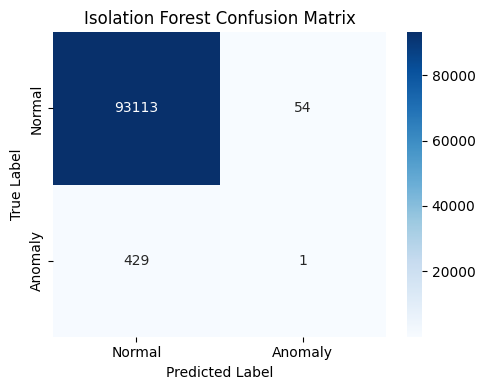

In [54]:
cm = confusion_matrix(y_test, if_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.title("Isolation Forest Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## Autoencoder (Unsupervised)

In [55]:
X_train_normal = X_train[y_train == 0]
print(f"Training autoencoder on {len(X_train_normal):,} normal rows")

Training autoencoder on 297,308 normal rows


In [56]:
input_dim = X_train.shape[1]
print("Input dimension:", input_dim)

Input dimension: 10


In [57]:
autoencoder = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(input_dim, activation='linear')
])


In [58]:
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,618 (25.85 KB)

 Trainable params: 6,618 (25.85 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


In [ ]:
train_recon = autoencoder.predict(X_train_normal)
train_mse = np.mean(np.power(X_train_normal - train_recon, 2), axis=1)
threshold = np.mean(train_mse) + 2 * np.std(train_mse)
print(f"Reconstruction error threshold: {threshold:.6f}")

9291/9291 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step
Reconstruction error threshold: 0.001236


In [ ]:
test_recon = autoencoder.predict(X_test)
test_mse = np.mean(np.power(X_test - test_recon, 2), axis=1)
ae_preds = (test_mse > threshold).astype(int)

print("\n=== Autoencoder ===")
print(classification_report(y_test, ae_preds, target_names=["Normal", "Anomaly"]))
print(f"ROC-AUC: {roc_auc_score(y_test, ae_preds):.4f}")

2925/2925 ━━━━━━━━━━━━━━━━━━━━ 3s 910us/step

=== Autoencoder ===
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     93167
     Anomaly       0.02      0.05      0.03       430

    accuracy                           0.99     93597
   macro avg       0.51      0.52      0.51     93597
weighted avg       0.99      0.99      0.99     93597

ROC-AUC: 0.5185


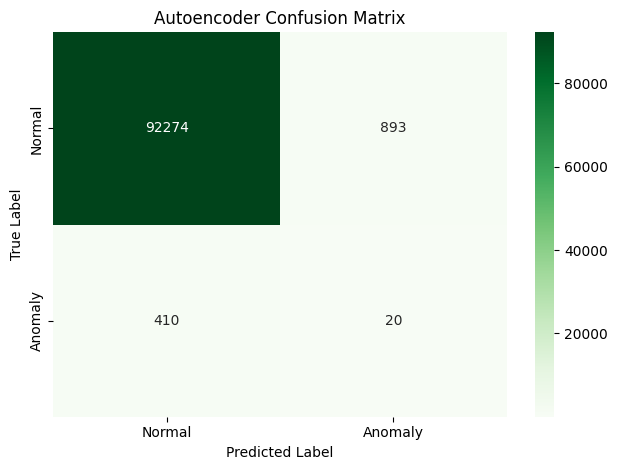

In [ ]:
cm_ae = confusion_matrix(y_test, ae_preds)
plt.Figure(figsize=(5,4))
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Greens',xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.title("Autoencoder Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## Model Comparison — ROC Curves

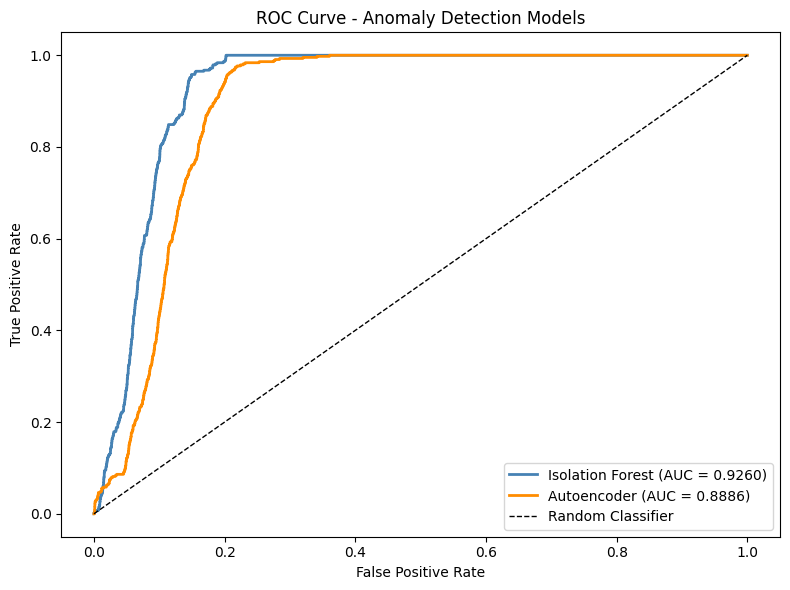

Isolation Forest AUC: 0.9260
Autoencoder AUC: 0.8886


In [ ]:
if_scores = -iso_forest.decision_function(X_test)
ae_scores = test_mse

fpr_if, tpr_if, _ = roc_curve(y_test, if_scores)
fpr_ae, tpr_ae, _ = roc_curve(y_test, ae_scores)

auc_if = auc(fpr_if, tpr_if)
auc_ae = auc(fpr_ae, tpr_ae)

plt.figure(figsize=(8,6))
plt.plot(fpr_if, tpr_if, label=f"Isolation Forest (AUC = {auc_if:.4f})", color='steelblue', lw=2)
plt.plot(fpr_ae, tpr_ae, label=f"Autoencoder (AUC = {auc_ae:.4f})", color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Anomaly Detection Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Isolation Forest AUC: {auc_if:.4f}")
print(f"Autoencoder AUC: {auc_ae:.4f}")

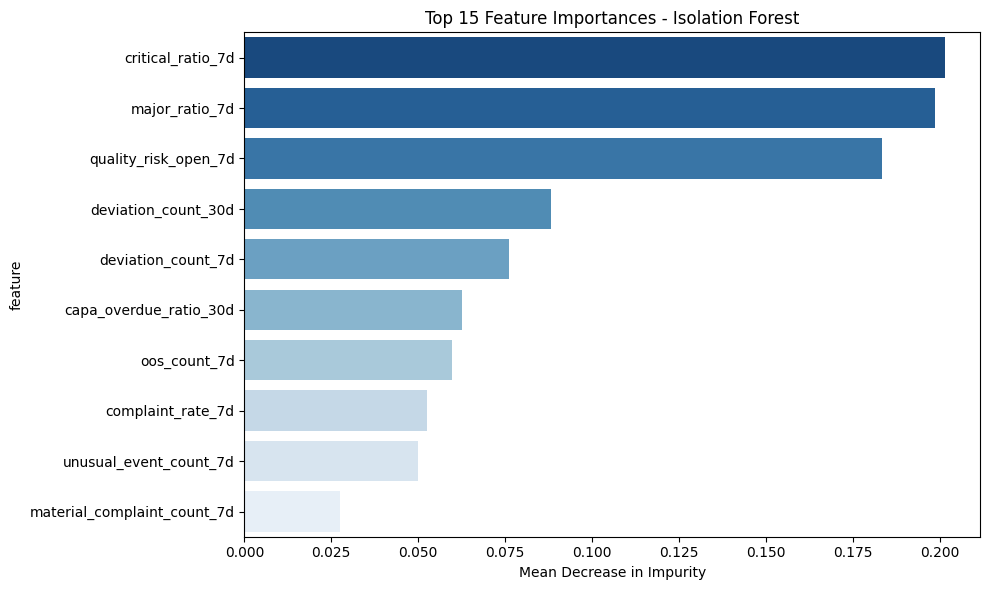

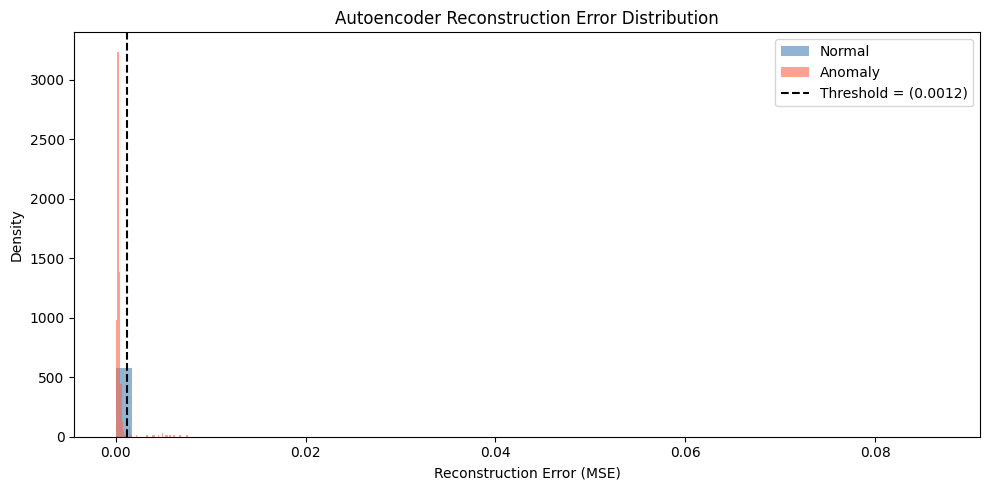

In [ ]:
importances = np.mean([tree.feature_importances_ for tree in iso_forest.estimators_], axis=0)

feature_imp_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_imp_df,x="importance", y="feature", palette="Blues_r")
plt.title("Top 15 Feature Importances - Isolation Forest")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

# AE reconstruction error distribution — normal vs anomaly 
normal_errors = test_mse[y_test == 0]
anomaly_errors = test_mse[y_test == 1]

plt.figure(figsize=(10, 5))
plt.hist(normal_errors, bins=50, alpha=0.6, label='Normal', color='steelblue', density=True)
plt.hist(anomaly_errors, bins=50, alpha=0.6, label='Anomaly', color='tomato', density=True)
plt.axvline(threshold, color='black', linestyle='--', label=f"Threshold = ({threshold:.4f})")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Density")
plt.title("Autoencoder Reconstruction Error Distribution")
plt.legend()
plt.tight_layout()
plt.show()

### XGBoost — Supervised Anomaly Detection

Unlike Isolation Forest and Autoencoder (both unsupervised), XGBoost uses the `is_anomaly` labels during training. This makes it a supervised approach that learns the actual definition of anomaly from ground truth labels.

In [ ]:
import xgboost as xgb
from sklearn.metrics import average_precision_score, precision_recall_curve

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")
print(f"Train — Normal: {(y_train==0).sum():,} | Anomaly: {(y_train==1).sum():,}")

Class imbalance ratio (scale_pos_weight): 173.46
Train — Normal: 297,308 | Anomaly: 1,714


In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print(f"Best iteration: {xgb_model.best_iteration}")

[0]	validation_0-aucpr:0.09174
[50]	validation_0-aucpr:0.08489
[53]	validation_0-aucpr:0.08585
Best iteration: 23


In [ ]:
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost (Supervised) ===")
print(classification_report(y_test, xgb_preds, target_names=["Normal", "Anomaly"]))
print(f"ROC-AUC:  {roc_auc_score(y_test, xgb_probs):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, xgb_probs):.4f}")

=== XGBoost (Supervised) ===
              precision    recall  f1-score   support

      Normal       1.00      0.88      0.94     93167
     Anomaly       0.03      0.69      0.05       430

    accuracy                           0.88     93597
   macro avg       0.51      0.79      0.49     93597
weighted avg       0.99      0.88      0.93     93597

ROC-AUC:  0.9072
PR-AUC:   0.1481


Optimal threshold: 0.7859
Precision: 0.3344
Recall:    0.2419
F1:        0.2807

=== XGBoost at Optimal Threshold ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     93167
     Anomaly       0.33      0.24      0.28       430

    accuracy                           0.99     93597
   macro avg       0.67      0.62      0.64     93597
weighted avg       0.99      0.99      0.99     93597



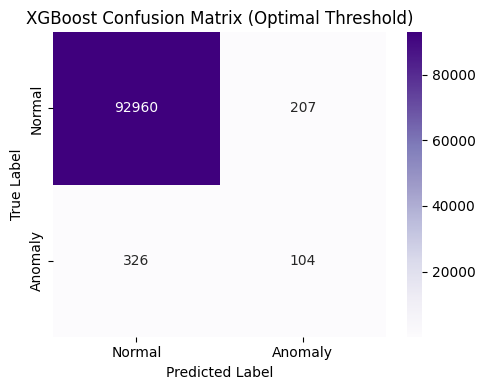

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Precision: {precisions[best_idx]:.4f}")
print(f"Recall:    {recalls[best_idx]:.4f}")
print(f"F1:        {f1_scores[best_idx]:.4f}")

xgb_preds_opt = (xgb_probs >= best_threshold).astype(int)
print("\n=== XGBoost at Optimal Threshold ===")
print(classification_report(y_test, xgb_preds_opt, target_names=["Normal", "Anomaly"]))

cm_xgb = confusion_matrix(y_test, xgb_preds_opt)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.title("XGBoost Confusion Matrix (Optimal Threshold)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

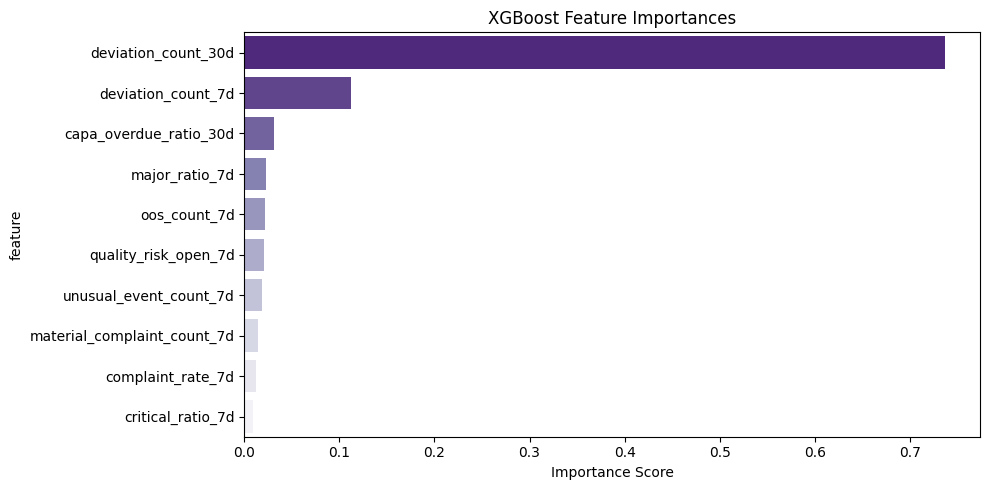

In [ ]:
xgb_feat_imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=xgb_feat_imp, x="importance", y="feature", palette="Purples_r")
plt.title("XGBoost Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

### MLFlow Logging

In [ ]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Serum-anomaly-detection")

with mlflow.start_run(run_name="Isolation-Forest"):
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("contamination", contamination)
    report_if = classification_report(y_test, if_preds, target_names=["Normal", "Anomaly"], output_dict=True)
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, if_preds))
    mlflow.log_metric("precision_anomaly", report_if["Anomaly"]["precision"])
    mlflow.log_metric("recall_anomaly", report_if["Anomaly"]["recall"])
    mlflow.log_metric("f1_anomaly", report_if["Anomaly"]["f1-score"])
    mlflow.sklearn.log_model(iso_forest, "isolation_forest")
    print("IF logged.")

2026/05/05 16:03:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 16:03:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


IF logged.
🏃 View run Isolation-Forest at: http://localhost:5000/#/experiments/1/runs/1ab6fb9caf784833b037700b41757f6e
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [ ]:
with mlflow.start_run(run_name="Autoencoder"):
    mlflow.log_param("architecture", "64-32-16-32-64")
    mlflow.log_param("threshold", float(threshold))
    report_ae = classification_report(y_test, ae_preds, target_names=["Normal", "Anomaly"], output_dict=True)
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, ae_preds))
    mlflow.log_metric("precision_anomaly", report_ae["Anomaly"]["precision"])
    mlflow.log_metric("recall_anomaly", report_ae["Anomaly"]["recall"])
    mlflow.log_metric("f1_anomaly", report_ae["Anomaly"]["f1-score"])
    mlflow.keras.log_model(autoencoder, "autoencoder")
    print("Autoencoder logged.")

2026/05/05 16:03:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 16:03:28 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


Autoencoder logged.
🏃 View run Autoencoder at: http://localhost:5000/#/experiments/1/runs/c207e5580b9e4a3e935306cb69e35ab3
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [ ]:
with mlflow.start_run(run_name="XGBoost-Supervised"):
    mlflow.log_param("n_estimators", xgb_model.best_iteration)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("scale_pos_weight", round(scale_pos_weight, 2))
    mlflow.log_param("optimal_threshold", round(best_threshold, 4))
    report_xgb = classification_report(y_test, xgb_preds_opt, target_names=["Normal", "Anomaly"], output_dict=True)
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, xgb_probs))
    mlflow.log_metric("pr_auc", average_precision_score(y_test, xgb_probs))
    mlflow.log_metric("precision_anomaly", report_xgb["Anomaly"]["precision"])
    mlflow.log_metric("recall_anomaly", report_xgb["Anomaly"]["recall"])
    mlflow.log_metric("f1_anomaly", report_xgb["Anomaly"]["f1-score"])
    mlflow.xgboost.log_model(xgb_model, "xgboost")
    print("XGBoost logged.")

2026/05/05 16:03:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost logged.
🏃 View run XGBoost-Supervised at: http://localhost:5000/#/experiments/1/runs/c6feec1623894b7999d6f8f2517b04f2
🧪 View experiment at: http://localhost:5000/#/experiments/1


## Save Models

In [ ]:
MODELS_DIR = BASE_DIR / "models"

MODELS_DIR.mkdir(exist_ok=True)


In [ ]:
joblib.dump(iso_forest, MODELS_DIR / "isolation_forest.pkl")
joblib.dump(scaler, MODELS_DIR / "scaler.pkl")
joblib.dump(xgb_model, MODELS_DIR / "xgboost_model.pkl")
autoencoder.save(MODELS_DIR / "autoencoder.h5")

print("Saved:")
print(f"  {MODELS_DIR / 'isolation_forest.pkl'}")
print(f"  {MODELS_DIR / 'scaler.pkl'}")
print(f"  {MODELS_DIR / 'xgboost_model.pkl'}")
print(f"  {MODELS_DIR / 'autoencoder.h5'}")

Saved:
  /home/rushikesh/Music/models/isolation_forest.pkl
  /home/rushikesh/Music/models/scaler.pkl
  /home/rushikesh/Music/models/xgboost_model.pkl
  /home/rushikesh/Music/models/autoencoder.h5
